In [77]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S071_001_00000012.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S082_001_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S116_001_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S097_001_00000020.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S085_003_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S127_001_00000015.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S085_003_00000011.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S107_001_00000008.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S138_004_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S068_003_00000013.png
/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48/surprise/S126_004_00000010.png

In [78]:

# dataset_path = "/root/.cache/kagglehub/datasets/navneet0094/jafee-dataset/versions/1/jaffe"

# import os

# print(os.listdir(dataset_path)[:10])

# print(os.listdir(dataset_path))

In [79]:
from PIL import Image
import numpy as np
import os

data = []
labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}

dataset_path = "/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe"
# dataset_path = "/root/.cache/kagglehub/datasets/navneet0094/jafee-dataset/versions/1/jaffe"

for img_name in os.listdir(dataset_path):

    img_path = os.path.join(dataset_path, img_name)

    try:
        img = Image.open(img_path).convert('L')   # grayscale
        img = img.resize((48,48))

        img = np.array(img)

        # Example filename: KA.AN1.39.tiff
        emotion = img_name.split('.')[1][:2]

        label = emotion_map[emotion]

        data.append(img)
        labels.append(label)

    except Exception as e:
        print("Error loading:", img_name)
        print(e)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (213, 48, 48)
Labels: [0 1 2 3 4 5 6]


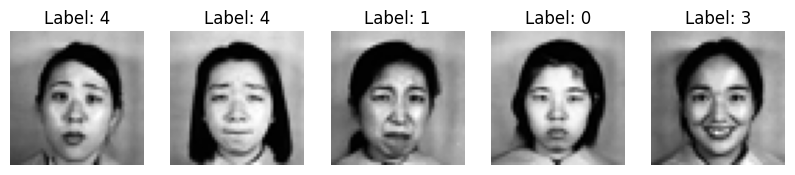

In [80]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

In [81]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (213, 900)


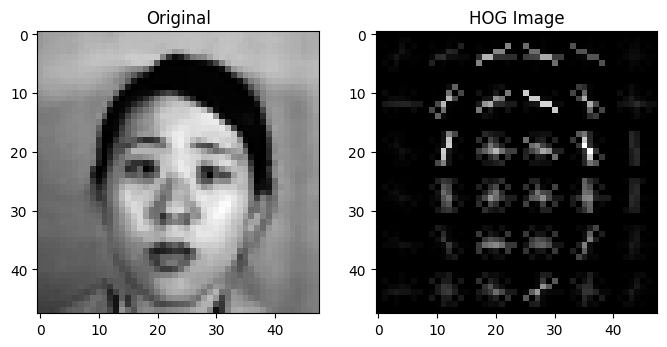

In [82]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, labels, test_size=0.3, random_state=42,shuffle=True
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = SVC(kernel='linear')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

hog_acc = accuracy_score(y_test, y_pred)

print("HOG Accuracy:", hog_acc)

HOG Accuracy: 0.625


In [85]:
emotion_names = ['anger','disgust','fear','happy','sadness','surprise','neutral']
print(classification_report(y_test, y_pred, target_names=emotion_names))

              precision    recall  f1-score   support

       anger       1.00      0.36      0.53        11
     disgust       0.17      0.50      0.25         4
        fear       0.71      0.62      0.67         8
       happy       0.73      0.89      0.80         9
     sadness       0.42      0.71      0.53         7
    surprise       1.00      0.47      0.64        15
     neutral       0.82      0.90      0.86        10

    accuracy                           0.62        64
   macro avg       0.69      0.64      0.61        64
weighted avg       0.78      0.62      0.64        64



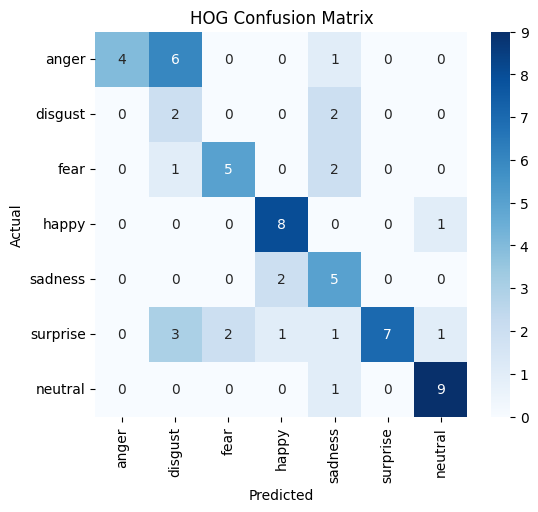

In [86]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("HOG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [87]:
# =========================
# LBP FEATURES
# =========================

from skimage.feature import local_binary_pattern

radius = 1
n_points = 8 * radius

X_lbp = []

for img in data:

    lbp = local_binary_pattern(
        img,
        n_points,
        radius,
        method='uniform'
    )

    # Histogram
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")

    # Normalize histogram
    hist /= (hist.sum() + 1e-6)

    X_lbp.append(hist)

X_lbp = np.array(X_lbp)

print("LBP feature shape:", X_lbp.shape)

LBP feature shape: (213, 10)


In [88]:
# =========================
# TRAIN TEST FOR LBP
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_lbp,
    labels,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lbp_model = SVC(kernel='linear')

lbp_model.fit(X_train, y_train)

y_pred_lbp = lbp_model.predict(X_test)

lbp_acc = accuracy_score(y_test, y_pred_lbp)

print("LBP Accuracy:", lbp_acc)

LBP Accuracy: 0.171875


In [89]:
# =========================
# SIFT DESCRIPTORS
# =========================

import cv2

sift = cv2.SIFT_create()

descriptor_list = []
all_descriptors = []

for img in data:

    img_uint8 = img.astype(np.uint8)

    keypoints, descriptors = sift.detectAndCompute(img_uint8, None)

    if descriptors is not None:

        descriptor_list.append(descriptors)
        all_descriptors.extend(descriptors)

    else:
        descriptor_list.append(np.array([]))

all_descriptors = np.array(all_descriptors)

print("Total descriptors:", all_descriptors.shape)

Total descriptors: (4310, 128)


In [90]:
# =========================
# KMEANS VISUAL WORDS
# =========================

from sklearn.cluster import MiniBatchKMeans

num_clusters = 50

kmeans = MiniBatchKMeans(
    n_clusters=num_clusters,
    random_state=42,
    batch_size=100
)

kmeans.fit(all_descriptors)

print("KMeans trained")

KMeans trained


In [91]:
# =========================
# KMEANS VISUAL WORDS
# =========================

from sklearn.cluster import MiniBatchKMeans

num_clusters = 50

kmeans = MiniBatchKMeans(
    n_clusters=num_clusters,
    random_state=42,
    batch_size=100
)

kmeans.fit(all_descriptors)

print("KMeans trained")

KMeans trained


In [92]:
# =========================
# BUILD SIFT HISTOGRAMS
# =========================

X_sift = []

for descriptors in descriptor_list:

    histogram = np.zeros(num_clusters)

    if descriptors.size != 0:

        cluster_result = kmeans.predict(descriptors)

        for i in cluster_result:
            histogram[i] += 1

    # Normalize
    histogram = histogram / (histogram.sum() + 1e-6)

    X_sift.append(histogram)

X_sift = np.array(X_sift)

print("SIFT feature shape:", X_sift.shape)

SIFT feature shape: (213, 50)


In [93]:
# =========================
# TRAIN TEST FOR SIFT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_sift,
    labels,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

sift_model = SVC(kernel='linear')

sift_model.fit(X_train, y_train)

y_pred_sift = sift_model.predict(X_test)

sift_acc = accuracy_score(y_test, y_pred_sift)

print("SIFT Accuracy:", sift_acc)

SIFT Accuracy: 0.28125


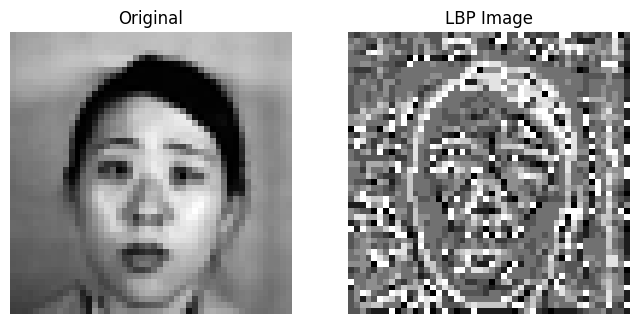

In [94]:
# =========================
# VISUALIZE LBP
# =========================

sample = data[0]

lbp_img = local_binary_pattern(
    sample,
    n_points,
    radius,
    method='uniform'
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(lbp_img, cmap='gray')
plt.title("LBP Image")
plt.axis('off')

plt.show()

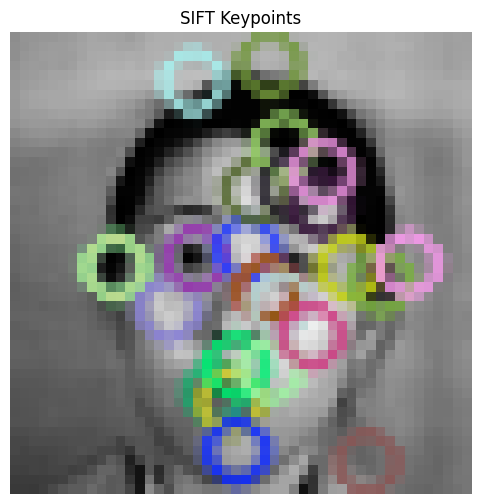

In [95]:
# =========================
# VISUALIZE SIFT KEYPOINTS
# =========================

sample = data[0].astype(np.uint8)

keypoints, descriptors = sift.detectAndCompute(sample, None)

sift_img = cv2.drawKeypoints(
    sample,
    keypoints,
    None
)

plt.figure(figsize=(6,6))

plt.imshow(sift_img)

plt.title("SIFT Keypoints")

plt.axis('off')

plt.show()

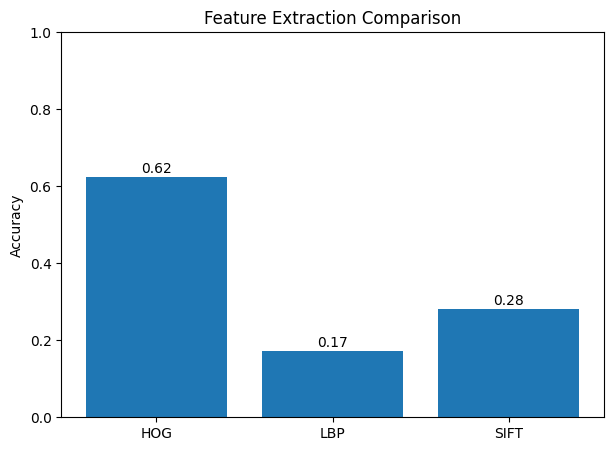

In [96]:
# =========================
# FINAL COMPARISON
# =========================

methods = ['HOG', 'LBP', 'SIFT']
accuracies = [hog_acc, lbp_acc, sift_acc]

plt.figure(figsize=(7,5))

bars = plt.bar(methods, accuracies)

plt.ylim(0, 1)

for bar, acc in zip(bars, accuracies):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        acc + 0.01,
        f"{acc:.2f}",
        ha='center'
    )

plt.title("Feature Extraction Comparison")
plt.ylabel("Accuracy")

plt.show()

In [97]:
data = []
labels = []

dataset_path = "/kaggle/input/datasets/gauravsharma99/ck48-5-emotions/CK+48"

for label, emotion in enumerate(os.listdir(dataset_path)):
    emotion_path = os.path.join(dataset_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (48,48))

        data.append(img)
        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (750, 48, 48)
Labels: [0 1 2 3 4]


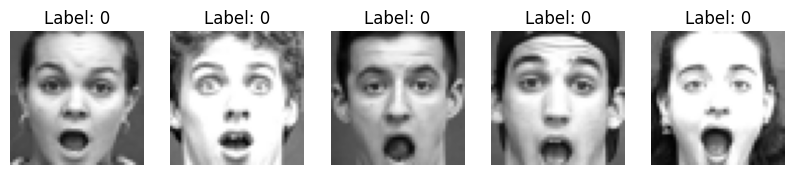

In [98]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

In [99]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (750, 900)


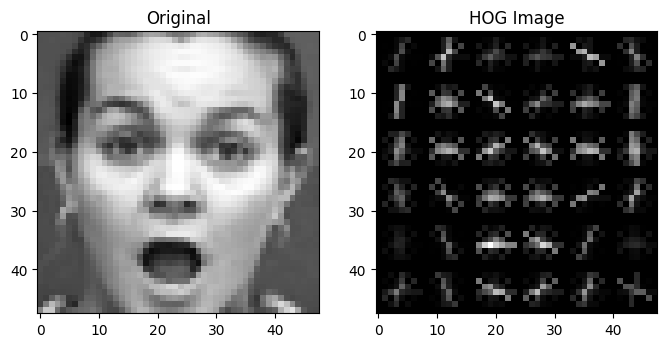

In [100]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [101]:
import time

* 

In [102]:
X_scaled = StandardScaler().fit_transform(X_hog)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42
)

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred = model.predict(X_test)

hog_acc = accuracy_score(y_test, y_pred)
hog_time = end - start

print("HOG Accuracy:", hog_acc)
print("HOG Time:", hog_time)

HOG Accuracy: 0.98
HOG Time: 0.06273841857910156


In [104]:
              precision    recall  f1-score   support

    surprise       1.00      1.00      1.00        52
        fear       0.82      1.00      0.90        14
     sadness       1.00      1.00      1.00        20
       happy       1.00      0.92      0.96        36
       anger       1.00      1.00      1.00        28

    accuracy                           0.98       150
   macro avg       0.96      0.98      0.97       150
weighted avg       0.98      0.98      0.98       150


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 5)

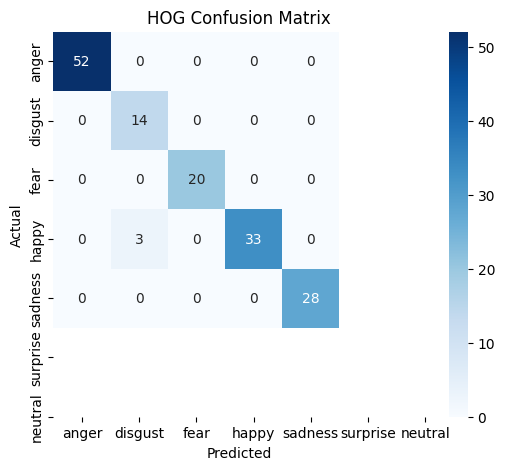

In [105]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names)

plt.title("HOG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [106]:
# # SIFT
# sift = cv2.SIFT_create()

# X_sift = []

# for img in data:
#     img = img.astype('uint8')

#     _, des = sift.detectAndCompute(img, None)

#     if des is None:
#         des = np.zeros(500)
#     else:
#         des = des.flatten()
#         if len(des) > 500:
#             des = des[:500]
#         else:
#             des = np.pad(des, (0, 500-len(des)))

#     X_sift.append(des)

# X_sift = np.array(X_sift)

# print("SIFT feature shape:", X_sift.shape)

SIFT feature shape: (750, 500)


In [117]:
# # SIFT vis

# sample_img = data[0].astype('uint8')
# kp, _ = sift.detectAndCompute(sample_img, None)

# img_kp = cv2.drawKeypoints(sample_img, kp, None)

# plt.imshow(img_kp, cmap='gray')
# plt.title("SIFT Keypoints")
# plt.show()

In [118]:
# X_scaled = StandardScaler().fit_transform(X_sift)

# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, labels, test_size=0.2, random_state=42,shuffle=False
# )

# start = time.time()

# model = SVC(kernel='linear')
# model.fit(X_train, y_train)

# end = time.time()

# y_pred1 = model.predict(X_test)

# sift_acc = accuracy_score(y_test, y_pred1)
# sift_time = end - start

# print("SIFT Accuracy:", sift_acc)
# print("SIFT Time:", sift_time)

In [109]:
# LBP
from skimage.feature import local_binary_pattern

X_lbp = []

for img in data:
    lbp = local_binary_pattern(img, 8, 1, method="uniform")
    # hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0,256))
    X_lbp.append(hist)

X_lbp = np.array(X_lbp)

print("LBP feature shape:", X_lbp.shape)

LBP feature shape: (750, 256)


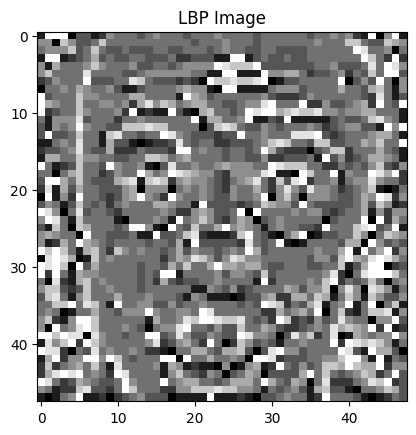

In [110]:
# lbp vis
sample_img = data[0]

lbp = local_binary_pattern(sample_img, 8, 1, method="uniform")

plt.imshow(lbp, cmap='gray')
plt.title("LBP Image")
plt.show()

In [111]:
X_scaled = StandardScaler().fit_transform(X_lbp)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42 ,shuffle =True
)

start = time.time()

model = SVC(kernel='linear')
model.fit(X_train, y_train)

end = time.time()

y_pred2 = model.predict(X_test)

lbp_acc = accuracy_score(y_test, y_pred2)
lbp_time = end - start

print("LBP Accuracy:", lbp_acc)
print("LBP Time:", lbp_time)

LBP Accuracy: 0.44
LBP Time: 0.05435514450073242


In [112]:
import cv2
import numpy as np

sift = cv2.SIFT_create()

descriptor_list = []
all_descriptors = []

for img in data:

    img_uint8 = img.astype(np.uint8)

    keypoints, descriptors = sift.detectAndCompute(img_uint8, None)

    if descriptors is not None:

        descriptor_list.append(descriptors)

        all_descriptors.extend(descriptors)

    else:
        descriptor_list.append(None)

all_descriptors = np.array(all_descriptors)

print("Total descriptors:", all_descriptors.shape)

Total descriptors: (21109, 128)


In [113]:
from sklearn.cluster import MiniBatchKMeans

num_clusters = 50

kmeans = MiniBatchKMeans(
    n_clusters=num_clusters,
    random_state=42,
    batch_size=100
)

kmeans.fit(all_descriptors)

print("Vocabulary created")

Vocabulary created


In [114]:
X_sift = []

for descriptors in descriptor_list:

    histogram = np.zeros(num_clusters)

    if descriptors is not None:

        cluster_result = kmeans.predict(descriptors)

        for i in cluster_result:
            histogram[i] += 1

    # normalize histogram
    histogram = histogram / (histogram.sum() + 1e-6)

    X_sift.append(histogram)

X_sift = np.array(X_sift)

print("SIFT feature shape:", X_sift.shape)

SIFT feature shape: (750, 50)


In [115]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_sift,
    labels,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [116]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='linear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

sift_acc = accuracy_score(y_test, y_pred)

print(" SIFT Accuracy:", sift_acc)

Correct SIFT Accuracy: 0.8266666666666667


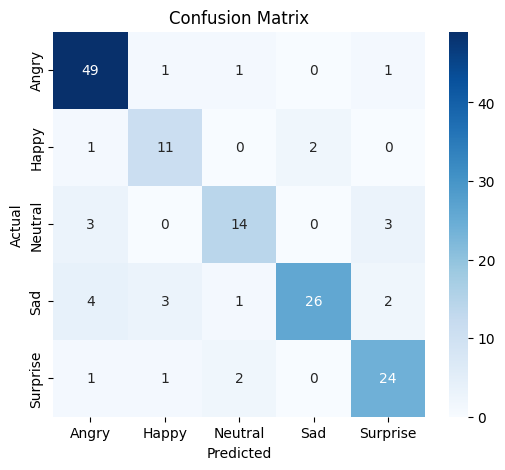

In [119]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

emotion_names = ['Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()